In [11]:
!pip install --no-cache-dir stable-baselines3

In [12]:
!pip install tiktoken torch

In [13]:
!pip install gymnasium[classic_control,box2d] stable-baselines3 shimmy tiktoken
import gymnasium as gym
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy

tried to add as many comments as i could to explain everything

In [14]:
# create log directories to store the training logs (scores, time, etc.)
os.makedirs("./logs/cartpole/", exist_ok=True)
os.makedirs("./logs/lunarlander/", exist_ok=True)

# 1. train CartPole (DQN).
print("Training CartPole (DQN)")
try:
    # gym.make initializes the game environment where the agent will play and monitor wraps the environment to record the rewards into the log folder
    env_cp = Monitor(gym.make("CartPole-v1"), "./logs/cartpole/")
except:
    # backup if local gym uses a different version
    env_cp = Monitor(gym.make("CartPole-v0"), "./logs/cartpole/")

# DQN is algorithm, MlpPolicy means it uses a standard Neural Network, learning_rate is set to 3e-4 (magic number from homework instructions)
model_cp = DQN("MlpPolicy", env_cp, learning_rate=3e-4, verbose=0)
# .learn starts the training process for 10,000 steps of the game
model_cp.learn(total_timesteps=10000)

# 2. train LunarLander (PPO)
print("Training LunarLander (PPO)")
# initializing LunarLander v3
env_ll = Monitor(gym.make("LunarLander-v3"), "./logs/lunarlander/")
model_ll = PPO("MlpPolicy", env_ll, learning_rate=3e-4, verbose=0)
# training for a larger amount of steps because of the increased difficulty in the task
model_ll.learn(total_timesteps=30000)

print("RL Training Complete.")

Training CartPole (DQN)
Training LunarLander (PPO)


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


RL Training Complete.


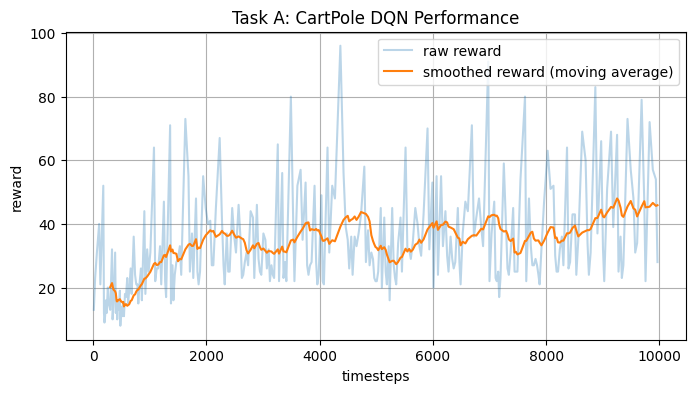

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


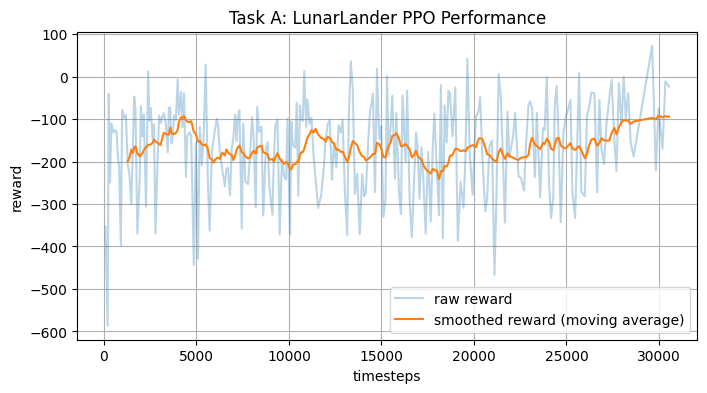

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
# plotting results
def plot_rl_results(log_folder, title):
    x, y = ts2xy(load_results(log_folder), 'timesteps')
    y_smoothed = pd.Series(y).rolling(window=15).mean()

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, alpha=0.3, label='raw reward')
    plt.plot(x, y_smoothed, label='smoothed reward (moving average)')
    plt.title(title)
    plt.xlabel('timesteps')
    plt.ylabel('reward')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_rl_results("./logs/cartpole/", "Task A: CartPole DQN Performance")
plot_rl_results("./logs/lunarlander/", "Task A: LunarLander PPO Performance")

task b

a. Tokenization Strategy: The current code uses a simple character-level mapping
(stoi/itos). Implement a sub-word tokenizer using the tiktoken library.

In [16]:
import tiktoken

# download file from github
!wget -O tips_ML_Phenotype.txt https://raw.githubusercontent.com/TTAyanlade/vlm/main/tips_ML_Phenotype.txt

# open the file and saves into the variable 'text'
with open('tips_ML_Phenotype.txt', 'r', encoding='utf-8') as f:
    text = f.read()

enc = tiktoken.get_encoding("gpt2")
data = torch.tensor(enc.encode(text), dtype=torch.long)


# take 90% of the data for training and leave 10% for validation ("Using the same tips-ML-Phenotype.txt dataset provided in the notebook, with a 90:10 train-val data split of tokenized data")
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]


# takes small,random chunks of data for ai to read while training
def get_batch(split, block_size, batch_size):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix]) # input
    y = torch.stack([d[i+1:i+block_size+1] for i in ix]) # target
    return x, y

# print for varification
print(f"dataset loaded. total tokens: {len(data)}")
print(f"vocabulary size for Tiktoken: {enc.n_vocab}")

--2026-05-14 18:46:04--  https://raw.githubusercontent.com/TTAyanlade/vlm/main/tips_ML_Phenotype.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36739 (36K) [text/plain]
Saving to: ‘tips_ML_Phenotype.txt’

tips_ML_Phenotype.t 100%[===================>]  35.88K  --.-KB/s    in 0.002s  

2026-05-14 18:46:04 (16.0 MB/s) - ‘tips_ML_Phenotype.txt’ saved [36739/36739]

dataset loaded. total tokens: 8623
vocabulary size for Tiktoken: 50257


In [17]:
class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=256):
        super().__init__()
        # pre-calculate the frequencies used for the rotation, which is based on the dim size
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, seq_len, device):
      # creates a list of positions, multiple position by freq, duplicate freq to match vector size, return cos and sin of angles
        t = torch.arange(seq_len, device=device).type_as(self.inv_freq)
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        return emb.cos(), emb.sin()

# splits vector in half
def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

# reshape cos/sin
def apply_rotary_pos_emb(q, k, cos, sin):
    # Adjust cos/sin shapes for broadcasting: (1, 1, T, head_dim)
    cos, sin = cos[None, None, :, :], sin[None, None, :, :]
    # rotation formula
    q_out = (q * cos) + (rotate_half(q) * sin)
    k_out = (k * cos) + (rotate_half(k) * sin)
    return q_out, k_out

In [18]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        self.n_head = n_head
        self.head_size = n_embd // n_head
        # gets all three vectors at once
        self.qkv = nn.Linear(n_embd, n_embd * 3, bias=False)
        self.proj = nn.Linear(n_embd, n_embd)

    def forward(self, x, cos, sin):
        # batch, time, channels
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_size).transpose(1, 2)

        # apply RoPE to Q and K
        q, k = apply_rotary_pos_emb(q, k, cos, sin)

        att = (q @ k.transpose(-2, -1)) * (self.head_size**-0.5)
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
        att = att.masked_fill(mask == 0, float('-inf'))
        att = F.softmax(att, dim=-1)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)

class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        self.sa = MultiHeadAttention(n_embd, n_head, block_size)
        self.ffwd = nn.Sequential(nn.Linear(n_embd, 4*n_embd), nn.ReLU(), nn.Linear(4*n_embd, n_embd))
        self.ln1, self.ln2 = nn.LayerNorm(n_embd), nn.LayerNorm(n_embd)

    def forward(self, x, cos, sin):
        x = x + self.sa(self.ln1(x), cos, sin)
        x = x + self.ffwd(self.ln2(x))
        return x

class SimpleTransformer(nn.Module):
    def __init__(self, n_layer, n_embd, n_head, block_size, vocab_size):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.rope = RotaryEmbedding(n_embd // n_head)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, block_size) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.token_emb(idx)
        cos, sin = self.rope(T, x.device)

        for block in self.blocks:
            x = block(x, cos, sin)

        logits = self.lm_head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        return logits, loss

In [19]:
# c. Hyperparameter Tuning: Perform a search across n-layer (4, 6, 8) and n-embd (64,128, 256) and report the final pretraining loss for each setting
n_layers_list = [4, 6, 8]
n_embds_list = [64, 128, 256]
block_size, batch_size = 32, 16
vocab_size = enc.n_vocab

results_table = []

for nl in n_layers_list:
    for ne in n_embds_list:
        print(f"training Config: Layers={nl}, Embedding={ne}...")
        model = SimpleTransformer(nl, ne, n_head=4, block_size=block_size, vocab_size=vocab_size)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

        # short training to demo
        model.train()
        for _ in range(100):
            xb, yb = get_batch('train', block_size, batch_size)
            _, loss = model(xb, yb)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        # report final loss
        model.eval()
        xv, yv = get_batch('val', block_size, batch_size)
        _, val_loss = model(xv, yv)
        results_table.append({"n_layer": nl, "n_embd": ne, "val_loss": val_loss.item()})

# print task b report
df = pd.DataFrame(results_table)
print("task b report")
print(df.to_string(index=False))

training Config: Layers=4, Embedding=64...
training Config: Layers=4, Embedding=128...
training Config: Layers=4, Embedding=256...
training Config: Layers=6, Embedding=64...
training Config: Layers=6, Embedding=128...
training Config: Layers=6, Embedding=256...
training Config: Layers=8, Embedding=64...
training Config: Layers=8, Embedding=128...
training Config: Layers=8, Embedding=256...
task b report
 n_layer  n_embd  val_loss
       4      64  6.809419
       4     128  7.131106
       4     256  6.510860
       6      64  7.244919
       6     128  6.640118
       6     256  5.622971
       8      64  7.070340
       8     128  6.698436
       8     256  6.141086


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
